# Домашнее задание 4
**Цель:** Обучить регрессионную модель аппроксимировать значение функции sin(x + 2*y) * exp(-(2x + y)^2) на диапазоне [-10; 10].

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Фиксируем генератор случайных чисел для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

### Часть 1. Генерация датасета и разделение на Train/Test/Val

In [9]:
# Генерируем 20 000 случайных точек на диапазоне [-10, 10]
num_samples = 20000
X_raw = np.random.uniform(-10, 10, size=(num_samples, 2))

x = X_raw[:, 0]
y = X_raw[:, 1]

# Вычисляем истинные значения функции
y_raw = np.sin(x + 2 * y) * np.exp(-((2 * x + y) ** 2))
y_raw = y_raw.reshape(-1, 1)

X_tensor = torch.tensor(X_raw, dtype=torch.float32)
y_tensor = torch.tensor(y_raw, dtype=torch.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X_tensor, y_tensor, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

Train size: 14000
Val size: 3000
Test size: 3000


### Часть 2. Архитектура нейросети и обучение

In [10]:
class RegressionModel(nn.Module):
    def __init__(self):  # <--- Исправлено здесь
        super(RegressionModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

# Заново инициализируем модель и оптимизатор
model = RegressionModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_X.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
        
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")

Epoch 01 | Train MSE: 0.048859 | Val MSE: 0.015463
Epoch 10 | Train MSE: 0.014523 | Val MSE: 0.011891
Epoch 20 | Train MSE: 0.011214 | Val MSE: 0.008149
Epoch 30 | Train MSE: 0.009641 | Val MSE: 0.007778
Epoch 40 | Train MSE: 0.005355 | Val MSE: 0.002925
Epoch 50 | Train MSE: 0.001707 | Val MSE: 0.001662


### Часть 3. Результаты и визуализация

In [12]:
# а) Расчет MSE на тесте
model.eval()
with torch.no_grad():
    test_preds = model(X_test)
    test_mse = criterion(test_preds, y_test).item()

print(f"MSE на тестовой выборке: {test_mse:.6f}")

MSE на тестовой выборке: 0.001314


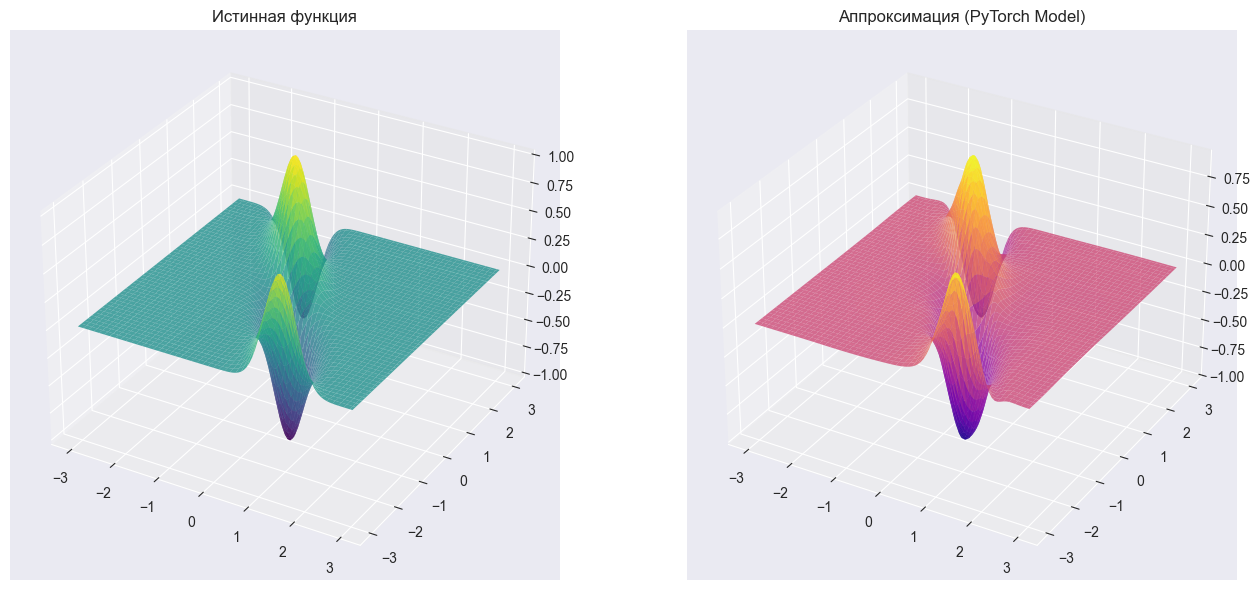

In [13]:
# b) Построение графиков
grid_x, grid_y = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
grid_flat = np.vstack([grid_x.ravel(), grid_y.ravel()]).T

z_true = np.sin(grid_flat[:, 0] + 2 * grid_flat[:, 1]) * np.exp(-((2 * grid_flat[:, 0] + grid_flat[:, 1]) ** 2))
z_true = z_true.reshape(grid_x.shape)

grid_tensor = torch.tensor(grid_flat, dtype=torch.float32)
with torch.no_grad():
    z_pred = model(grid_tensor).numpy().reshape(grid_x.shape)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(grid_x, grid_y, z_true, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_title('Истинная функция')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(grid_x, grid_y, z_pred, cmap='plasma', edgecolor='none', alpha=0.8)
ax2.set_title('Аппроксимация (PyTorch Model)')

plt.tight_layout()
plt.show()